In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_parquet("../data/processed/loans_clean.parquet")

# Portfolio summary
total_monthly_cf = df["installment"].sum()
print(f"Total scheduled monthly cash flow: ${total_monthly_cf:,.0f}")
print(f"Number of loans: {len(df):,}")
print(f"Average installment: ${df['installment'].mean():.2f}")
print(f"Overall delinquency rate: {df['delq90'].mean():.2%}")

Total scheduled monthly cash flow: $1,006,874,746
Number of loans: 2,258,957
Average installment: $445.73
Overall delinquency rate: 12.87%


In [2]:
# Baseline buffer calculation
# Logic: if a loan goes 90-day delinquent, we lose 3 months of installments
# Buffer needed = expected monthly CF lost × 3 months

p_delq = df["delq90"].mean()
monthly_cf = df["installment"].sum()

expected_monthly_loss = monthly_cf * p_delq
baseline_buffer = expected_monthly_loss * 3

print("=" * 50)
print("BASELINE BUFFER ESTIMATE")
print("=" * 50)
print(f"Portfolio monthly cash flow:  ${monthly_cf:>15,.0f}")
print(f"Delinquency rate:             {p_delq:>15.2%}")
print(f"Expected monthly CF loss:     ${expected_monthly_loss:>15,.0f}")
print(f"90-day buffer (3 months):     ${baseline_buffer:>15,.0f}")
print(f"Buffer as % of monthly CF:    {baseline_buffer/monthly_cf:>15.2%}")

# By grade
print("\nBuffer by grade:")
grade_buf = (df.groupby("grade")
               .agg(monthly_cf=("installment", "sum"),
                    delq_rate=("delq90", "mean"))
               .assign(buffer=lambda x: x["monthly_cf"] * x["delq_rate"] * 3))

print(grade_buf[["monthly_cf", "delq_rate", "buffer"]]
      .style.format({"monthly_cf": "${:,.0f}",
                     "delq_rate": "{:.2%}",
                     "buffer": "${:,.0f}"}))

BASELINE BUFFER ESTIMATE
Portfolio monthly cash flow:  $  1,006,874,746
Delinquency rate:                      12.87%
Expected monthly CF loss:     $    129,586,667
90-day buffer (3 months):     $    388,760,001
Buffer as % of monthly CF:             38.61%

Buffer by grade:


In [3]:
print(grade_buf[["monthly_cf", "delq_rate", "buffer"]].to_string())

         monthly_cf  delq_rate        buffer
grade                                       
A      1.894273e+08   0.035899  2.040094e+07
B      2.755978e+08   0.086615  7.161253e+07
C      2.834350e+08   0.143668  1.221620e+08
D      1.541790e+08   0.203648  9.419457e+07
E      7.153332e+07   0.282991  6.072980e+07
F      2.467146e+07   0.364383  2.696957e+07
G      8.030870e+06   0.400296  9.644182e+06


In [4]:
# Monte Carlo simulation
# Instead of using a single delinquency rate, we sample from a distribution
# to get a range of possible outcomes and pick a conservative percentile

np.random.seed(42)
N_SIM = 50_000

# Use Beta distribution fitted to observed delinquency rate
# Beta(a, b) where a = successes, b = failures
n_loans = len(df)
n_delq  = df["delq90"].sum()

a = n_delq
b = n_loans - n_delq

# Simulate delinquency rates
sim_rates = np.random.beta(a, b, N_SIM)

# Simulate cash flow shortfall for each scenario
sim_shortfall = sim_rates * total_monthly_cf * 3

print("=" * 55)
print("MONTE CARLO BUFFER ESTIMATION (50,000 simulations)")
print("=" * 55)
print(f"Mean simulated rate:      {sim_rates.mean():.4%}")
print(f"Std dev:                  {sim_rates.std():.6f}")
print()
print(f"50th percentile buffer:   ${np.percentile(sim_shortfall, 50):>15,.0f}")
print(f"90th percentile buffer:   ${np.percentile(sim_shortfall, 90):>15,.0f}")
print(f"95th percentile buffer:   ${np.percentile(sim_shortfall, 95):>15,.0f}")
print(f"99th percentile buffer:   ${np.percentile(sim_shortfall, 99):>15,.0f}")
print(f"99.9th percentile buffer: ${np.percentile(sim_shortfall, 99.9):>15,.0f}")
print()
print(f"As % of monthly CF:")
for pct in [50, 90, 95, 99]:
    val = np.percentile(sim_shortfall, pct)
    print(f"  {pct}th pct: {val/total_monthly_cf:.2%}")

MONTE CARLO BUFFER ESTIMATION (50,000 simulations)
Mean simulated rate:      12.8703%
Std dev:                  0.000223

50th percentile buffer:   $    388,763,582
90th percentile buffer:   $    389,622,883
95th percentile buffer:   $    389,875,480
99th percentile buffer:   $    390,321,018
99.9th percentile buffer: $    390,806,096

As % of monthly CF:
  50th pct: 38.61%
  90th pct: 38.70%
  95th pct: 38.72%
  99th pct: 38.77%


In [ ]:
# Enhanced simulation: add parameter uncertainty
# A real lender doesn't know the true delinquency rate
# We model uncertainty around our estimate using a wider prior

np.random.seed(42)
N_SIM = 50_000

# Stress scenarios — what if the rate is higher than observed?
# (e.g. economic downturn, portfolio quality shift)
scenarios = {
    "Base (observed 12.9%)":     p_delq,
    "Mild stress (+25%)":        p_delq * 1.25,
    "Moderate stress (+50%)":    p_delq * 1.50,
    "Severe stress (2007 peak)": 0.35,   # worst cohort we observed
}

results = []
for scenario, rate in scenarios.items():
    shortfalls = rate * total_monthly_cf * 3
    results.append({
        "Scenario":        scenario,
        "Delinq rate":     rate,
        "Buffer required": shortfalls,
        "% of monthly CF": shortfalls / total_monthly_cf,
    })

results_df = pd.DataFrame(results)
print("=" * 70)
print("STRESS-TESTED BUFFER SCENARIOS")
print("=" * 70)
for _, row in results_df.iterrows():
    print(f"\n{row['Scenario']}")
    print(f"  Delinquency rate:  {row['Delinq rate']:.2%}")
    print(f"  Buffer required:   ${row['Buffer required']:,.0f}")
    print(f"  % of monthly CF:   {row['% of monthly CF']:.2%}")

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue", "goldenrod", "darkorange", "crimson"]
bars = ax.barh(results_df["Scenario"],
               results_df["Buffer required"] / 1e6,
               color=colors, alpha=0.8)

for bar, val in zip(bars, results_df["Buffer required"]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"${val/1e6:.0f}M", va="center", fontsize=9)

ax.set_xlabel("Required buffer ($M)")
ax.set_title("Cash-flow buffer requirement under stress scenarios")
ax.set_xlim(0, results_df["Buffer required"].max() / 1e6 * 1.2)

plt.tight_layout()
plt.savefig("../output/figures/buffer_scenarios.png", dpi=150)
plt.show()

BUFFER SENSITIVITY TABLE ($M) — varying delinquency & recovery rates
            Recovery 0% Recovery 20% Recovery 40% Recovery 60%
Delinq rate                                                   
5%                $151M        $121M         $91M         $60M
10%               $302M        $242M        $181M        $121M
12%               $362M        $290M        $217M        $145M
15%               $453M        $362M        $272M        $181M
20%               $604M        $483M        $362M        $242M
25%               $755M        $604M        $453M        $302M
35%              $1057M        $846M        $634M        $423M


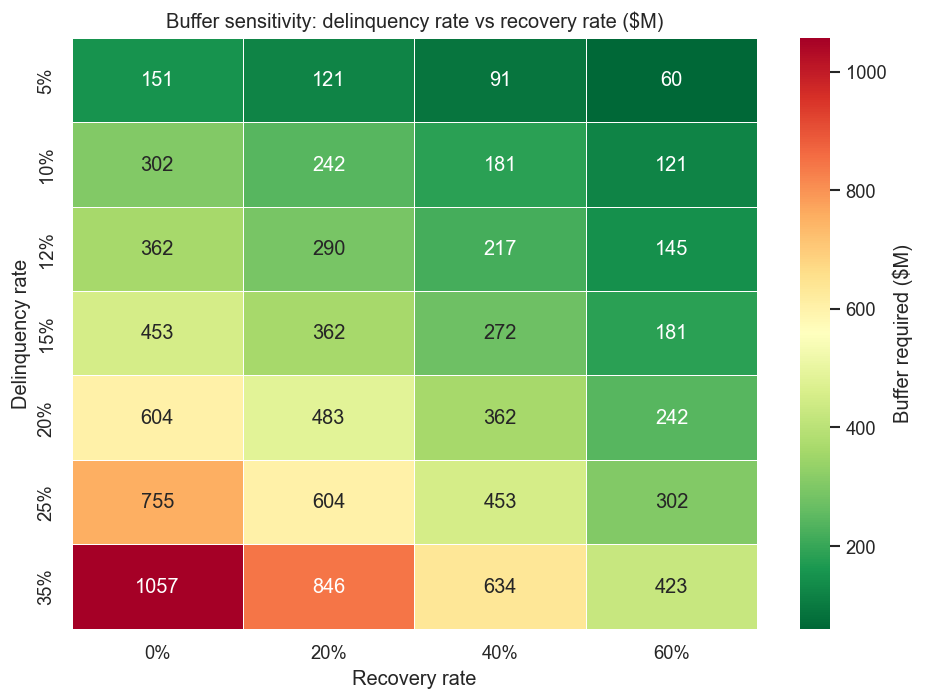

In [6]:
# Sensitivity table: buffer vs delinquency rate vs recovery rate
delq_rates  = [0.05, 0.10, 0.12, 0.15, 0.20, 0.25, 0.35]
recovery_rates = [0.0, 0.2, 0.4, 0.6]

monthly_cf = total_monthly_cf
rows = []
for d in delq_rates:
    row = {"Delinq rate": f"{d:.0%}"}
    for r in recovery_rates:
        # Net loss = delinquent CF × 3 months × (1 - recovery)
        net_loss = monthly_cf * d * 3 * (1 - r)
        row[f"Recovery {r:.0%}"] = f"${net_loss/1e6:.0f}M"
    rows.append(row)

sens_df = pd.DataFrame(rows).set_index("Delinq rate")

print("=" * 70)
print("BUFFER SENSITIVITY TABLE ($M) — varying delinquency & recovery rates")
print("=" * 70)
print(sens_df.to_string())

# Heatmap version
fig, ax = plt.subplots(figsize=(8, 6))
heat_data = pd.DataFrame([
    [monthly_cf * d * 3 * (1-r) / 1e6
     for r in recovery_rates]
    for d in delq_rates
], index=[f"{d:.0%}" for d in delq_rates],
   columns=[f"{r:.0%}" for r in recovery_rates])

sns.heatmap(heat_data, annot=True, fmt=".0f", cmap="RdYlGn_r",
            ax=ax, linewidths=0.5,
            cbar_kws={"label": "Buffer required ($M)"})

ax.set_xlabel("Recovery rate")
ax.set_ylabel("Delinquency rate")
ax.set_title("Buffer sensitivity: delinquency rate vs recovery rate ($M)")
plt.tight_layout()
plt.savefig("../output/figures/buffer_sensitivity.png", dpi=150)
plt.show()